# Exercise 1: Introduction to the Switchboard Environment

This notebook is your first introduction to the Switchboard environment. The goal is to learn how to set up the environment, interact with it, and understand its basic mechanics. This will prepare you for implementing more sophisticated learning algorithms in later exercises. Make yourself familiar with the underlying [RealTimeEnvironment](../environments/README.md) and the [SwitchBoard](../environments/switchboard/README.md) implementation before proceeding with the exercise.

First, we import the required classes:

In [3]:
import os
import time
import torch
from matplotlib import pyplot as plt
# Set the working directory to the root of the repository
if os.path.basename(os.getcwd()) == 'exercises':
    os.chdir('../')

from environments.switchboard.switchboard import Switchboard
from environments.switchboard.switchboard import Rule
from environments.switchboard.switchboard import LambdaRule
from environments.switchboard.switchboard import RuleBuilder
from environments.switchboard.pygame_interface import SwitchboardPygameInterface

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Using device: {device}')

pygame 2.2.0 (SDL 2.32.54, Python 3.11.14)
Hello from the pygame community. https://www.pygame.org/contribute.html
Using device: cpu


/home/mwuerstle@corp.exxcellent.de/miniconda3/envs/agi/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


---

## Task 1: PyGame Interface

Before we start programmatically interacting with the Switchboard envrionment, use the provided PyGame Interface to interact with the environment yourself. You can run the interface using the 'direct_rules' scenario like this:
```bash
python environments/switchboard/pygame_interface.py --scenario direct_rules
python environments/switchboard/pygame_interface.py --scenario hard_rules

```

More scenarios can be found here [scenarios.py](../environments/switchboard/scenarios/scenarios.py)
Alternatively, you can run import the PyGame Interface directly and run it from code:

In [5]:
env = Switchboard(
    action_dim=10, 
    obs_dim=10, 
    time_scaling=0.0,  # 0.0 means turn-taking mode
    device=device, 
    scenario='direct_rules' # some scenario
)

interface = SwitchboardPygameInterface(
    env,
    auto_policy=None,  # if you already have a policy you can use this to execute your policy
)

# Run the interface
interface.run()

✓ Loaded 6 rules from DirectRules
Interface closed


Or if you need more control, you can call the render functions yourself:

In [4]:
interface = SwitchboardPygameInterface(
    env,
    auto_policy=None,  # if you already have a policy you can use this to execute your policy
)
interface.handle_events() # keyboard inputs


True

In [11]:
obs, info = env.step(lambda obs: torch.randint(0, 2, (env.action_dim,), device=device))  # Perform action in the environment   
interface.handle_events() # keyboard inputs
interface.render(obs.squeeze(), info["performed_action"]) #render last action and observation


In [12]:
interface.close()

---
## Task 2: First Interaction - Turn Traking
Next, we want to interact with the environment using the python API.

The Switchboard environment can operate in two modes: **turn-taking** and **real-time**. We'll start with the simpler one: turn-taking.
In turn-taking mode (`time_scaling=0.0`), the environment waits for your policy to return an action, executes it for a single step, and then returns the new observation. 
Let's initialize the environment. We'll load the `direct_rules` scenario, which contains a simple set of rules mapping combinations of buttons to single slots.

In [13]:
env = Switchboard(
    action_dim=10, 
    obs_dim=10, 
    time_scaling=0.0,  # 0.0 means turn-taking mode
    device=device, 
    scenario='direct_rules'
)

print("Environment created!")
print("Action dimension:", env.action_dim)
print("Observation dimension:", env.obs_dim)

✓ Loaded 6 rules from DirectRules
Environment created!
Action dimension: 10
Observation dimension: 10


To interact with the environment, we need a **policy**. A policy is simply a function that takes an `observation` tensor and returns an `action` tensor.

**Tasks:** 
- Create a simple policy that always presses **button 0**. Remember that actions are binary tensors (0 for not pressed, 1 for pressed).
- Execute the policy, print the resulting observation and info dictionary

In [17]:
def policy(observation: torch.Tensor) -> torch.Tensor:
    action = torch.zeros((env.action_dim,), device=device)
    action[0] = 1  # Press button 0
    return action

interface = SwitchboardPygameInterface(
    env,
    auto_policy=None,  # if you already have a policy you can use this to execute your policy
)
interface.handle_events() # keyboard inputs


obs, info = env.step(policy)  # Perform action in the environment
print(f"Performed Action: {info['performed_action'].squeeze().cpu().numpy()}, Observation: {obs.squeeze().cpu().numpy()}")
print(f"Info: {info}")
interface.render(obs.squeeze(), info["performed_action"]) #render last action and observation
time.sleep(5)
interface.close()


Performed Action: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.], Observation: [0.         0.         0.         0.         0.         0.
 0.04236025 0.         0.         0.        ]
Info: {'num_environment_steps': 1, 'actual_policy_time_ms': 0.27887699980055913, 'benchmark_policy_time_ms': -1, 'simulation_step_time_ms': -1, 'actual_simulation_time_ms': 4.700811000475369, 'time_scaling': 0.0, 'step_count': 145, 'performed_action': tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])}


**Expected Output:** If your policy is correct, you should see that `action[0]` is 1, and `observation[0]` in the next step is also 1. This is because the `direct_rules` scenario maps button 0 directly to observation slot 0.

---

## Task 3: Rule Discovery

The "direct_rules" scenario consists of 6 simple direct and independent rules, where **combinations of buttons** result in **single active slots**. You can treat each slot as independent, focusing on only one slot at a time. 

**Tasks**: 
- Discover all rules by interacting with the environment
- Print the list of discovered rules using the code below.


### Solution 1:

In [ ]:
import torch

def random_policy(obs):
    """A simple policy that returns random actions."""
    return torch.randint(0, 2, (env.action_dim,), device=device).float()


discovered_rules_dict = {}
print("Starting rule discovery...")

for i in range(5000):
    obs, info = env.step(random_policy) 
    
    performed_action = info['performed_action']

    # Only consider single-slot activations as possible rules
    if obs.sum() == 1:
        slot_index = obs.argmax().item()
        current_action_sum = torch.sum(performed_action)

        # Check if this slot was activated before
        if slot_index not in discovered_rules_dict and performed_action.sum() > 0:
            # This is a brand new rule. Add it.
            discovered_rules_dict[slot_index] = performed_action
            print(f'  [NEW] Rule {len(discovered_rules_dict)} for slot {slot_index}: Action {performed_action.cpu().numpy()} (Sum: {current_action_sum})')
        
        else: # Rule was activated before. Check if less actions are required:
            existing_action = discovered_rules_dict[slot_index]
            existing_action_sum = torch.sum(existing_action)
            
            if current_action_sum < existing_action_sum:
                # The new action is better (less actions). Update the rule.
                print(f'  [UPDATE] Slot {slot_index}: Action {performed_action.cpu().numpy()} (Sum: {current_action_sum}) replaces {existing_action.cpu().numpy()} (Sum: {existing_action_sum})')
                discovered_rules_dict[slot_index] = performed_action


# Print the rules
print("\n--- Discovery Finished. Final Rules: ---")

discovered_rules = [
]

for slot_index, action in sorted(discovered_rules_dict.items()):
    observation = torch.zeros((1, env.obs_dim), device=device)
    observation[0, slot_index] = 1.0
    discovered_rules.append((action, observation))

for i, (action, observation) in enumerate(discovered_rules):
    active_buttons = action.nonzero().squeeze().cpu().numpy()
    active_observations = observation[0].nonzero().squeeze().cpu().numpy()
    print(f'Rule {i}:  Buttons: {active_buttons} -> Slots: {active_observations}')
    

To verify your result you can access the environment's state to retreive the actual rules:

In [ ]:
rules = env.list_rules()
for i, rule in enumerate(rules):
    print(f"Rule {i}: {rule['description']}")

### Solution 2:

In [ ]:
# iterate over all possible actions, store action and observation tuples
data = []
action_dim = env.action_dim
num_actions = 2**action_dim

indices = torch.arange(num_actions, dtype=torch.int64, device=device)

all_actions = ((indices.unsqueeze(1) >> torch.arange(action_dim, device=device)) & 1).float() 

# 3. Iterate over the generated actions
for action in all_actions:
    obs, info = env.step(lambda obs: action)  # Perform action in the environment
    data.append((action, obs))
    
    
    
    # process obs and info as needed
# for each observation find the smallest possible action from all actions triggering a single slot
discovered_rules = []
for slot_index in range(env.obs_dim):
    matching_actions = [action for action, obs in data if obs.sum() == 1 and obs.argmax().item() == slot_index]
    if matching_actions:
        # find the action with the smallest number of active buttons
        best_action = min(matching_actions, key=lambda a: a.sum())
        observation = torch.zeros((1, env.obs_dim), device=device)
        observation[0, slot_index] = 1.0
        discovered_rules.append((best_action, observation))

for i, (action, observation) in enumerate(discovered_rules):
    active_buttons = action.nonzero().squeeze().cpu().numpy()
    active_observations = observation[0].nonzero().squeeze().cpu().numpy()
    print(f'Rule {i}:  Buttons: {active_buttons} -> Slots: {active_observations}')


---

## Task 4: Understanding Real-Time Mode

Let's move to the real-time mode (`time_scaling > 0`). In this mode, the environment runs at a fixed speed and does not wait for your policy. 
If your policy's computation is delayed, the environment will execute multiple simulation steps before receiving your next action. The number of environment steps depends on a reference policy, which is meant to run in turn-taking mode. 
If your actual policy execution is slower than this reference policy, more environment steps are performed. Thus, it is essential to first have a benchmarking step to evaluate the reference policy:

In [10]:

rt_env = Switchboard(
    action_dim=10, 
    obs_dim=10, 
    time_scaling=1.0,  # Real-time mode; change this parameter to balance number of steps vs. policy computation time
    device=device, 
    scenario='direct_rules'
)

# A simple random policy for as reference for benchmarking purposes
def benchmark_policy(observation): 
    return torch.randint(0, 2, (rt_env.action_dim,), device=device)

# Benchmark the policy and simulation
policy_time_ms = rt_env.benchmark_policy(benchmark_policy, num_trials=1000)
sim_time_ms = rt_env.benchmark_simulation(num_trials=1000)

print(f'Reference policy took on average {policy_time_ms:.4f} ms.')
print(f'Environment simulation took on average {sim_time_ms:.4f} ms.')

✓ Loaded 6 rules from DirectRules
Reference policy took on average 0.0054 ms.
Environment simulation took on average 0.1679 ms.



Now that we've setup the environment, we can run it in real-time mode using your actual policy. The `info` dictionary returned by `env.step()` becomes very important here. It contains a key `num_environment_steps`, which tells you how many simulation steps passed while your policy computed an action. Before running your policy, use the `warmup` function as caching and JIT compilation may introduce bottlenecks in the first few policy executions:

**Tasks:** 
- Run the real-time environment using the policy used for benchmarking and keep track of the number of environment steps performed during execution. Plot the results to see how the timing varies. For the reference policy you should get on average $1$ environment step per policy execution.
- Define an alternative policy with some heavy computation (you can simulate this by `time.sleep(seconds)` to introduce a delay), execute it and visualize the environment steps performed during policy execution.
- Define a neural network based policy and evaluate the performance

### Evaluating the reference policy

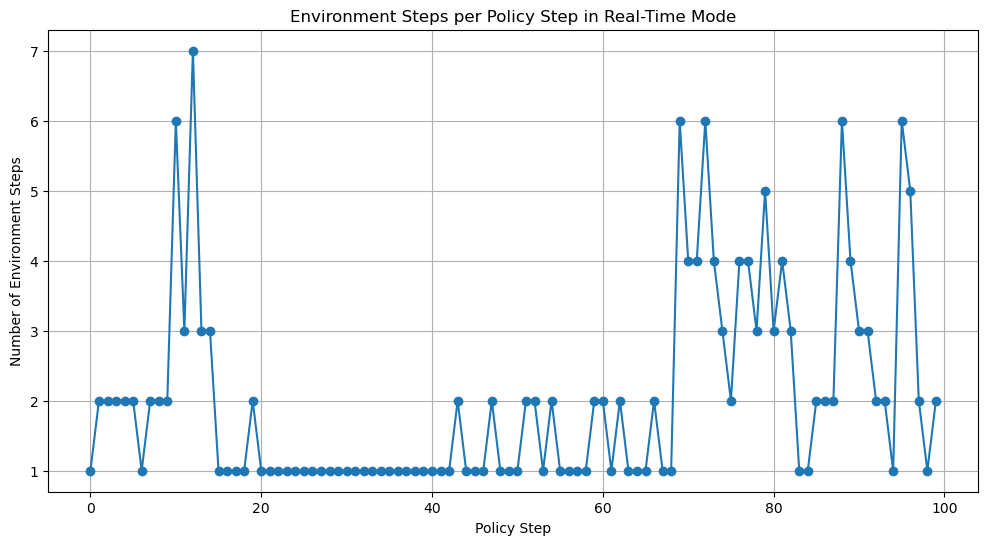

In [29]:

# Warm up the JIT compiler
rt_env.warmup(benchmark_policy, num_warmup_steps=100) 
rt_env.time_scaling = 1

num_steps_history = []
for i in range(100):
    obs, info = rt_env.step(benchmark_policy)
    num_steps_history.append(info['num_environment_steps'])


plt.figure(figsize=(12, 6))
plt.plot(num_steps_history, marker='o', linestyle='-')
plt.title('Environment Steps per Policy Step in Real-Time Mode')
plt.xlabel('Policy Step')
plt.ylabel('Number of Environment Steps')
plt.grid(True)
plt.show()

### Evaluating a slow policy

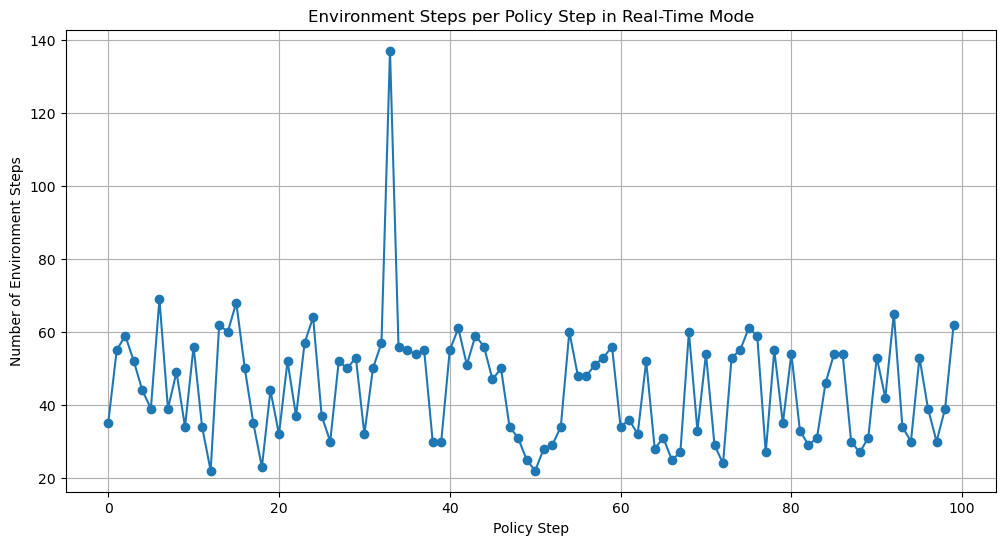

In [12]:
import time
def slow_policy(observation: torch.Tensor) -> torch.Tensor:
    """A policy that introduces a small, random delay to simulate computation."""
    # Simulate some 'thinking' time
    time.sleep(torch.rand(1).item() * 0.0001)

    action = torch.zeros(rt_env.action_dim, device=device)
    action[torch.randint(0, rt_env.action_dim, (1,))] = 1.0 # Press a random button
    return action

rt_env.warmup(slow_policy, num_warmup_steps=100) 

num_steps_history = []
for i in range(100):
    obs, info = rt_env.step(slow_policy)
    num_steps_history.append(info['num_environment_steps'])


plt.figure(figsize=(12, 6))
plt.plot(num_steps_history, marker='o', linestyle='-')
plt.title('Environment Steps per Policy Step in Real-Time Mode')
plt.xlabel('Policy Step')
plt.ylabel('Number of Environment Steps')
plt.grid(True)
plt.show()

### Evaluating a NN policy

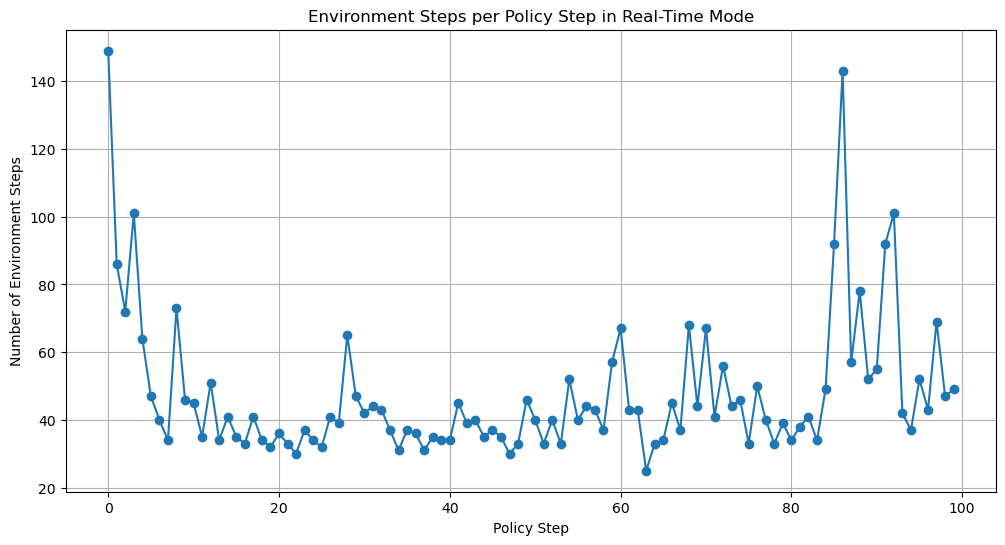

In [14]:
from torch import nn
class SimpleNNPolicy(torch.nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(SimpleNNPolicy, self).__init__()
        self.net = nn.Sequential(
            torch.nn.Linear(obs_dim, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, action_dim),
            torch.nn.Sigmoid()  # Output between 0 and 1
        )
    def forward(self, observation):
        # Assumed shape: (batch, time, features) 
        observation = observation.mean(dim=1) # average over time to deal with sequence
        return (self.net(observation) > 0.5).float()  # binary output 
    def get_policy(self):
        return lambda obs: self.forward(obs.unsqueeze(0)) # add batch dimension
    
nn_policy = SimpleNNPolicy(rt_env.obs_dim, rt_env.action_dim).to(device)

rt_env.time_scaling = 1.0 # we can change this outside of init

rt_env.warmup(nn_policy.get_policy(), num_warmup_steps=100)

num_steps_history = []
for i in range(100):
    obs, info = rt_env.step(nn_policy.get_policy())
    num_steps_history.append(info['num_environment_steps'])


plt.figure(figsize=(12, 6))
plt.plot(num_steps_history, marker='o', linestyle='-')
plt.title('Environment Steps per Policy Step in Real-Time Mode')
plt.xlabel('Policy Step')
plt.ylabel('Number of Environment Steps')
plt.grid(True)
plt.show()

# Task 5: Designing Custom Environments

### Using RuleBuilder (pre-defined rules)

In [15]:
env = Switchboard(
    action_dim=10, 
    obs_dim=10, 
    time_scaling=0.0,  # no time-scaling
    device=device
)

env.add_rule(RuleBuilder.toggle(0,0,strength=1, rule_id="toggle")) # toggle slot 0 if button 1 is pressed
env.add_rule(RuleBuilder.direct(1, 1))
env.add_rule(RuleBuilder.delayed(2,2,10,1))

interface = SwitchboardPygameInterface(
    env,
    auto_policy=None,  # if you already have a policy you can use this to execute your policy
)
interface.run()


Interface closed


### Using LambdaRules (simple functions)

In [16]:
env.rules = []

def evaluate_fn(actions, obs, state, step) -> torch.Tensor:
    obs_update = obs.clone()
    obs_update = obs_update * obs_update*0.99 # decay
    obs_update[obs_update <= 0.05] = 0.0
    idx = obs.argmax()
    if actions[0] == 1:
        idx = (idx + 1) % obs.shape[0]
    elif actions[1] == 1:
        idx = (idx - 1) % obs.shape[0]
    obs_update[idx] = 1.0
    return obs_update
custom_rule = LambdaRule("move_and_decay", evaluate_fn=evaluate_fn, description="Move active slot, decay inactive slots.")
env.add_rule(custom_rule)
interface = SwitchboardPygameInterface(
    env,
    auto_policy=None,  # if you already have a policy you can use this to execute your policy
)
interface.run()


Interface closed


### Using Rule class

In [17]:


class OscillateAndDecay(Rule):
    def __init__(self, rule_id, action_on_idx, action_off_idx, obs_idx, frequency=0.1):
        super().__init__(rule_id, f"Oscillate [on: {action_on_idx}, off: {action_off_idx}] -> {obs_idx}")
        self.action_on_idx = action_on_idx
        self.action_off_idx = action_off_idx
        self.obs_idx = obs_idx
        self.frequency = frequency
        self.phase = 0.0
        self.is_active = False

    def evaluate(self, actions, observations, step):
        obs_update = torch.zeros_like(observations)

        # Activate on button press
        if actions[self.action_on_idx] > 0:
            self.is_active = True
        if actions[self.action_off_idx] > 0:
            self.is_active = False
        # Generate oscillation if active
        if self.is_active:
            value = (torch.sin(torch.tensor(self.phase)).item() + 1.0) / 2.0
            obs_update[self.obs_idx] = value
            self.phase += self.frequency
        else:
            obs_update[self.obs_idx] = 0.9*observations[self.obs_idx]
        return obs_update

    def reset(self):
        super().reset()
        self.phase = 0.0
        self.is_active = False

# Add it to the environment
env.rules = []

env.add_rule(OscillateAndDecay("osc_dec", 7,8, 6, frequency=0.2))
interface = SwitchboardPygameInterface(
    env,
    auto_policy=None,  # if you already have a policy you can use this to execute your policy
)
interface.run()


Interface closed


---

## Conclusion

Congratulations! You have now learned how to:
1. Initialize the Switchboard environment in both turn-taking and real-time modes.
2. Define a policy function to control the agent's actions.
3. Interact with the environment using the pygame interface.
4. Discover & Explore the rules of a scenario.
5. Understand the implications of real-time execution.
6. Setup custom rules.
